In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('data/adult.csv', na_values='?')

df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [4]:

print(df.info())


missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              48842 non-null  int64
 1   workclass        46043 non-null  str  
 2   fnlwgt           48842 non-null  int64
 3   education        48842 non-null  str  
 4   educational-num  48842 non-null  int64
 5   marital-status   48842 non-null  str  
 6   occupation       46033 non-null  str  
 7   relationship     48842 non-null  str  
 8   race             48842 non-null  str  
 9   gender           48842 non-null  str  
 10  capital-gain     48842 non-null  int64
 11  capital-loss     48842 non-null  int64
 12  hours-per-week   48842 non-null  int64
 13  native-country   47985 non-null  str  
 14  income           48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB
None
workclass         2799
occupation        2809
native-country     857
dtype: int64


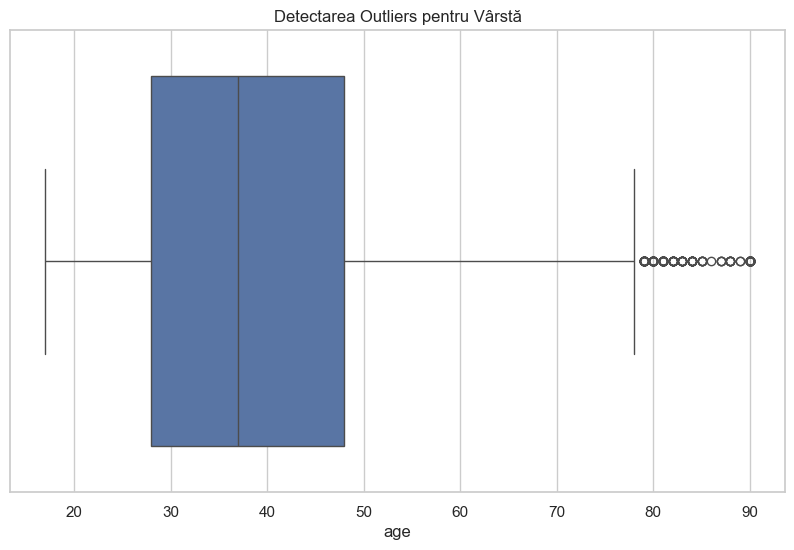

In [5]:

for col in ['workclass', 'occupation', 'native-country']:
    df[col] = df[col].fillna(df[col].mode()[0])

df = df.drop_duplicates()

sns.boxplot(x=df['age'])
plt.title('Detectarea Outliers pentru Vârstă')
plt.show()

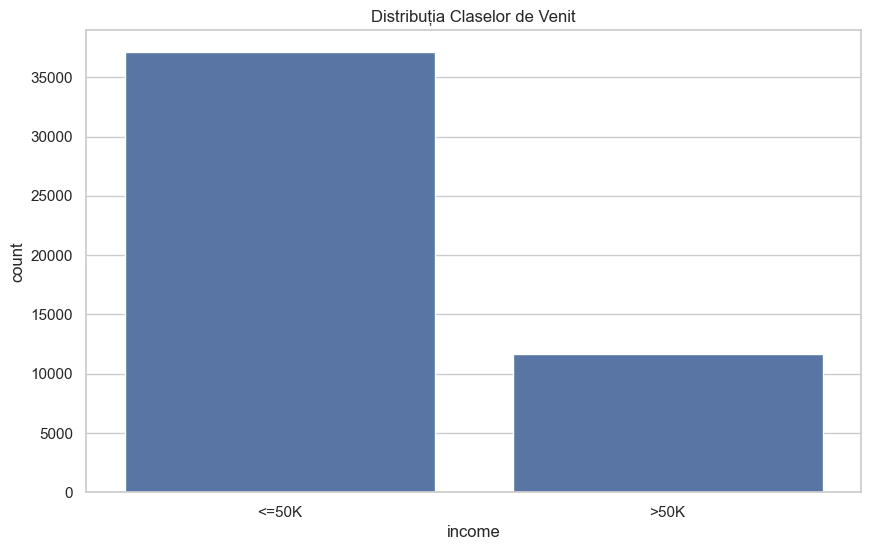

In [6]:
sns.countplot(data=df, x='income')
plt.title('Distribuția Claselor de Venit')
plt.show()

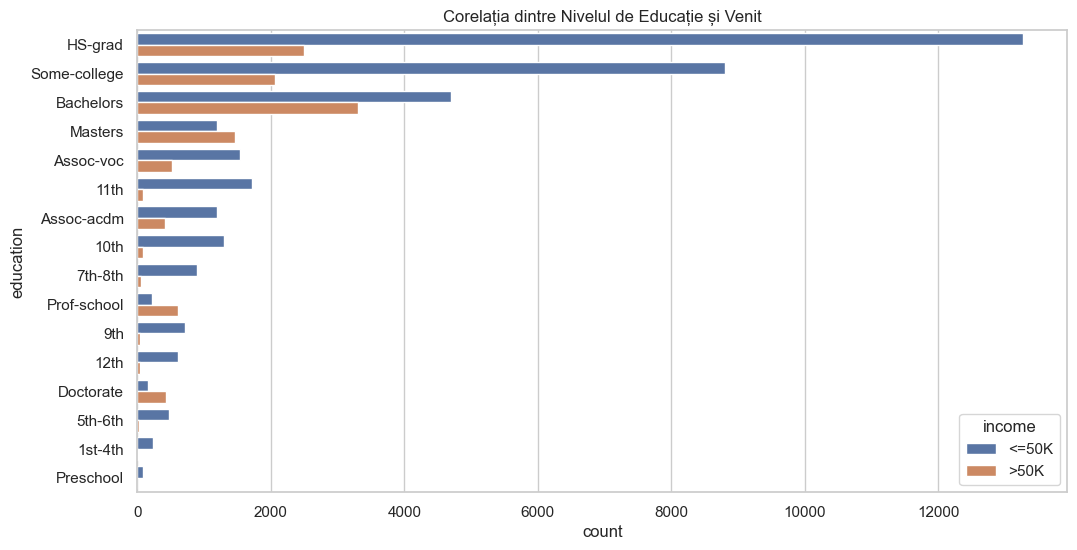

In [7]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='education', hue='income', order=df['education'].value_counts().index)
plt.title('Corelația dintre Nivelul de Educație și Venit')
plt.show()

In [8]:
from sklearn.preprocessing import LabelEncoder

df = df.drop('fnlwgt', axis=1)

df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})

df_final = pd.get_dummies(df, drop_first=True)

print(f"Număr total de coloane după One-Hot Encoding: {df_final.shape[1]}")

Număr total de coloane după One-Hot Encoding: 97


In [9]:
from sklearn.model_selection import train_test_split

X = df_final.drop('income', axis=1)
y = df_final['income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Eșantion antrenare: {X_train.shape[0]} observații")
print(f"Eșantion testare: {X_test.shape[0]} observații")

Eșantion antrenare: 36591 observații
Eșantion testare: 12198 observații


In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evalueaza_model(nume, model, X_test, y_test):
    X_test_input = X_test.values if hasattr(X_test, 'columns') else X_test

    y_pred = model.predict(X_test_input)
    y_proba = model.predict_proba(X_test_input)[:, 1] if hasattr(model, "predict_proba") else None

    return {
        "Model": nume,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba) if y_proba is not None else 0
    }

toate_rezultatele = []

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
X_train_final = X_train_scaled
X_test_final = X_test_scaled

In [13]:
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

nb = GaussianNB().fit(X_train_final, y_train)
toate_rezultatele = []
toate_rezultatele.append(evalueaza_model("Naïve Bayes", nb, X_test_final, y_test))

lr = LogisticRegression(max_iter=1000).fit(X_train_final, y_train)
toate_rezultatele.append(evalueaza_model("Logistic Regression", lr, X_test_final, y_test))

lr = LogisticRegression(max_iter=5000, solver='saga', tol=1e-3).fit(X_train_final, y_train)
toate_rezultatele.append(evalueaza_model("Logistic Regression", lr, X_test_final, y_test))
print("Logistic Regression a terminat fără erori!")

dt = DecisionTreeClassifier().fit(X_train_final, y_train)
toate_rezultatele.append(evalueaza_model("Decision Tree", dt, X_test_final, y_test))

print("Modelele rapide au fost antrenate!")

Logistic Regression a terminat fără erori!
Modelele rapide au fost antrenate!


In [15]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from interpret.glassbox import ExplainableBoostingClassifier

pd.util = pd._testing

print("Începe antrenarea modelelor complexe...")

rf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_final, y_train)
toate_rezultatele.append(evalueaza_model("Random Forest", rf, X_test_final, y_test))
print("- Random Forest gata.")

xgb = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss').fit(X_train_final, y_train)
toate_rezultatele.append(evalueaza_model("XGBoost", xgb, X_test_final, y_test))
print("- XGBoost gata.")

cat = CatBoostClassifier(iterations=500, verbose=0, random_state=42).fit(X_train_final, y_train)
toate_rezultatele.append(evalueaza_model("CatBoost", cat, X_test_final, y_test))
print("- CatBoost gata.")


ebm = ExplainableBoostingClassifier(random_state=42).fit(X_train_final, y_train)
toate_rezultatele.append(evalueaza_model("EBM", ebm, X_test_final, y_test))
print("- EBM gata.")

print("--- Toate modelele din Celula 3 au terminat! ---")

Începe antrenarea modelelor complexe...
- Random Forest gata.


D:\FACULTATE\SEM II\SI\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:14:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


- XGBoost gata.
- CatBoost gata.
- EBM gata.
--- Toate modelele din Celula 3 au terminat! ---


In [16]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

print("Începe antrenarea modelelor bazate pe distanță...")

knn = KNeighborsClassifier(n_neighbors=5).fit(X_train_final, y_train)
toate_rezultatele.append(evalueaza_model("K-Nearest Neighbors", knn, X_test_final, y_test))
print("- KNN gata.")


svm = SVC(probability=True, max_iter=2000, random_state=42).fit(X_train_final, y_train)
toate_rezultatele.append(evalueaza_model("SVM", svm, X_test_final, y_test))
print("- SVM gata.")

print("--- Toate modelele din Celula 4 au terminat! ---")

Începe antrenarea modelelor bazate pe distanță...
- KNN gata.


D:\FACULTATE\SEM II\SI\.venv\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


- SVM gata.
--- Toate modelele din Celula 4 au terminat! ---


In [17]:
import pandas as pd

df_comparativ = pd.DataFrame(toate_rezultatele)

df_comparativ = df_comparativ.sort_values(by="F1-Score", ascending=False).reset_index(drop=True)

print("Clasamentul final al modelelor (după F1-Score):")
display(df_comparativ)


Clasamentul final al modelelor (după F1-Score):


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,XGBoost,0.871372,0.795650,0.644186,0.711952,0.927809
1,EBM,0.869897,0.791957,0.641196,0.708647,0.928265
2,CatBoost,0.869569,0.794032,0.636545,0.706620,0.928383
3,Random Forest,0.844237,0.712481,0.618272,0.662042,0.887726
4,Random Forest,0.844237,0.712481,0.618272,0.662042,0.887726
5,Logistic Regression,0.847516,0.744058,0.582392,0.653373,0.905266
6,Logistic Regression,0.847762,0.745633,0.581395,0.653351,0.905352
7,Decision Tree,0.817183,0.638298,0.598007,0.617496,0.767027
8,K-Nearest Neighbors,0.820954,0.663370,0.557143,0.605634,0.839291
9,SVM,0.614691,0.367180,0.776080,0.498506,0.749492


In [18]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold


cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
rezultate_tuned = []

2. Optimizarea celor 5 modele

A. XGBoost (RandomizedSearchCV)


In [19]:
param_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

grid_xgb = RandomizedSearchCV(XGBClassifier(eval_metric='logloss'), param_xgb,
                               n_iter=10, cv=cv, scoring='f1', n_jobs=-1, random_state=42)
grid_xgb.fit(X_train_final, y_train)
rezultate_tuned.append(evalueaza_model("XGBoost_Tuned", grid_xgb.best_estimator_, X_test_final, y_test))

B. CatBoost (GridSearchCV)

In [20]:
param_cat = {
    'depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'iterations': [300]
}

grid_cat = GridSearchCV(CatBoostClassifier(verbose=0), param_cat, cv=cv, scoring='f1', n_jobs=-1)
grid_cat.fit(X_train_final, y_train)
rezultate_tuned.append(evalueaza_model("CatBoost_Tuned", grid_cat.best_estimator_, X_test_final, y_test))

C. Random Forest (RandomizedSearchCV)


In [21]:
param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 2, 4]
}

grid_rf = RandomizedSearchCV(RandomForestClassifier(), param_rf, n_iter=10, cv=cv, scoring='f1', n_jobs=-1)
grid_rf.fit(X_train_final, y_train)
rezultate_tuned.append(evalueaza_model("Random Forest_Tuned", grid_rf.best_estimator_, X_test_final, y_test))

D. Logistic Regression (GridSearchCV)


In [22]:
param_lr = {
    'C': [0.1, 1, 10],
    'l1_ratio': [0, 0.5, 1],
    'solver': ['saga'],
    'penalty': ['elasticnet']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=5000),
    param_lr,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)
grid_lr.fit(X_train_final, y_train)

rezultate_tuned.append(evalueaza_model("Logistic Regression_Tuned", grid_lr.best_estimator_, X_test_final, y_test))
print("Logistic Regression Tuned: Gata!")

D:\FACULTATE\SEM II\SI\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Logistic Regression Tuned: Gata!


E. EBM (Manual/Grid Tuning)


In [23]:
ebm_tuned = ExplainableBoostingClassifier(interactions=10, random_state=42).fit(X_train_final, y_train)
rezultate_tuned.append(evalueaza_model("EBM_Tuned", ebm_tuned, X_test_final, y_test))

In [23]:
df_tuned = pd.DataFrame(rezultate_tuned).sort_values(by="F1-Score", ascending=False)
display(df_tuned)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,XGBoost_Tuned,0.871372,0.793962,0.646512,0.712690,0.928545
4,EBM_Tuned,0.869159,0.793361,0.635216,0.705535,0.928500
1,CatBoost_Tuned,0.869159,0.794338,0.633887,0.705100,0.928345
2,Random Forest_Tuned,0.858255,0.781044,0.591362,0.673095,0.916555
3,Logistic Regression_Tuned,0.847516,0.744058,0.582392,0.653373,0.905320


In [24]:
df_tuned_final = df_tuned.drop_duplicates(subset=['Model']).reset_index(drop=True)
display(df_tuned_final)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,XGBoost_Tuned,0.871372,0.793962,0.646512,0.712690,0.928545
1,EBM_Tuned,0.869159,0.793361,0.635216,0.705535,0.928500
2,CatBoost_Tuned,0.869159,0.794338,0.633887,0.705100,0.928345
3,Random Forest_Tuned,0.858255,0.781044,0.591362,0.673095,0.916555
4,Logistic Regression_Tuned,0.847516,0.744058,0.582392,0.653373,0.905320


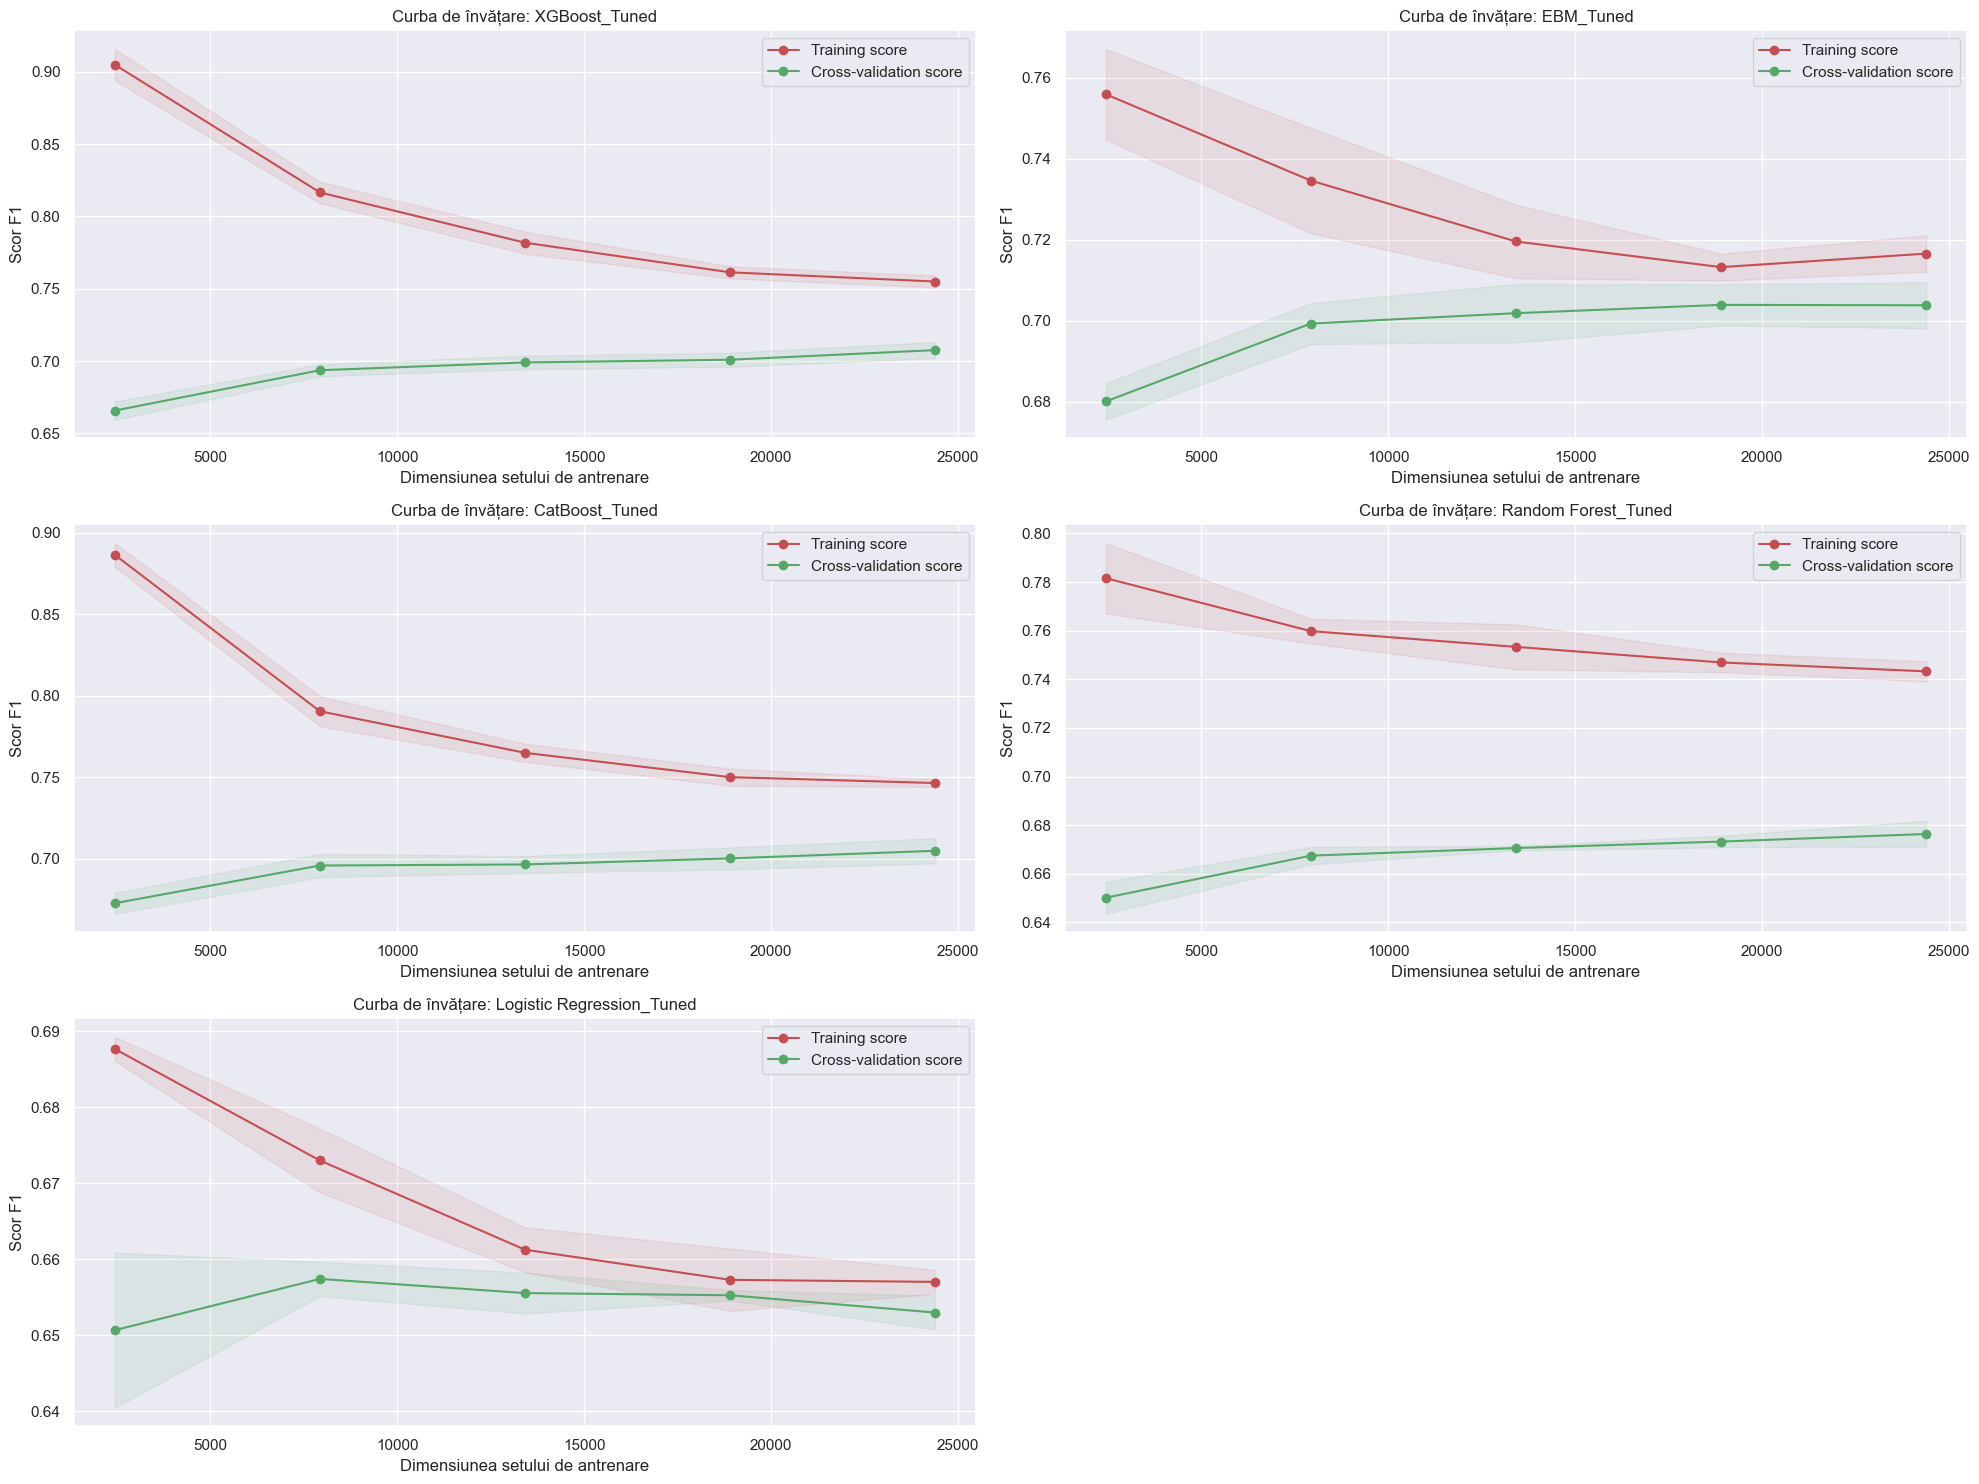

In [25]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

def plot_learning_curves(models_dict, X, y):
    plt.figure(figsize=(20, 15))

    for i, (name, model) in enumerate(models_dict.items(), 1):
        train_sizes, train_scores, test_scores = learning_curve(
            model, X, y, cv=3, n_jobs=-1,
            train_sizes=np.linspace(0.1, 1.0, 5), scoring='f1'
        )

        train_mean = np.mean(train_scores, axis=1)
        train_std = np.std(train_scores, axis=1)
        test_mean = np.mean(test_scores, axis=1)
        test_std = np.std(test_scores, axis=1)

        plt.subplot(3, 2, i)
        plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training score")
        plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation score")

        plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
        plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")

        plt.title(f"Curba de învățare: {name}")
        plt.xlabel("Dimensiunea setului de antrenare")
        plt.ylabel("Scor F1")
        plt.legend(loc="best")
        plt.grid(True)

best_5_tuned = {
    "XGBoost_Tuned": grid_xgb.best_estimator_,
    "EBM_Tuned": ebm_tuned,
    "CatBoost_Tuned": grid_cat.best_estimator_,
    "Random Forest_Tuned": grid_rf.best_estimator_,
    "Logistic Regression_Tuned": grid_lr.best_estimator_
}

plot_learning_curves(best_5_tuned, X_train_final, y_train)
plt.tight_layout()
plt.show()

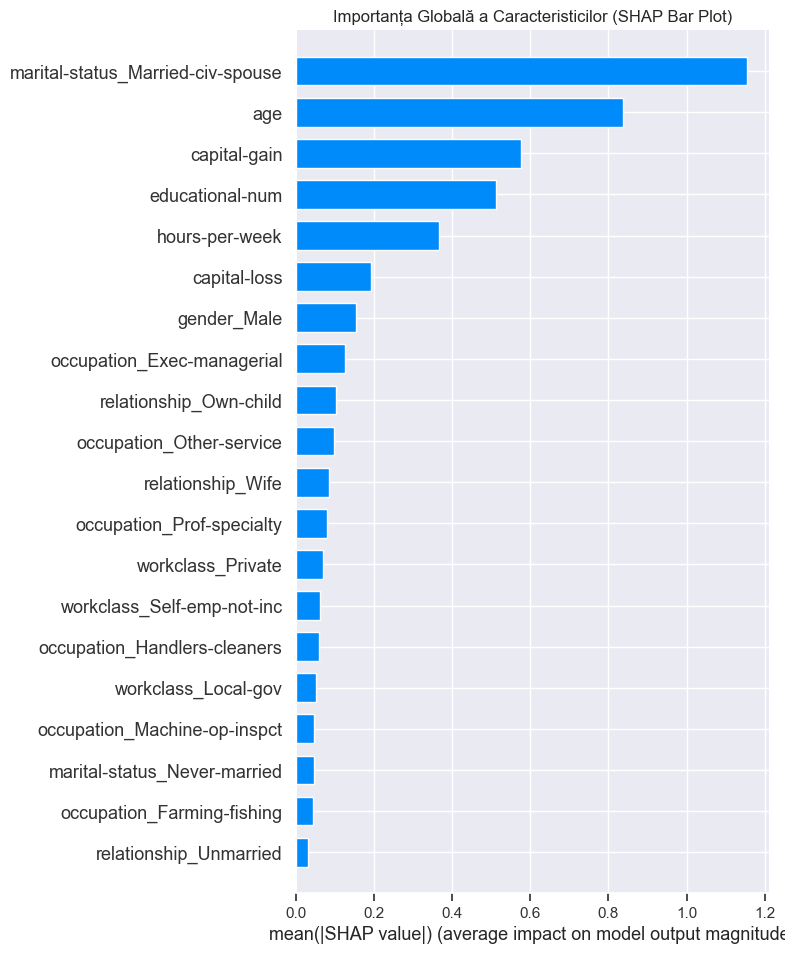

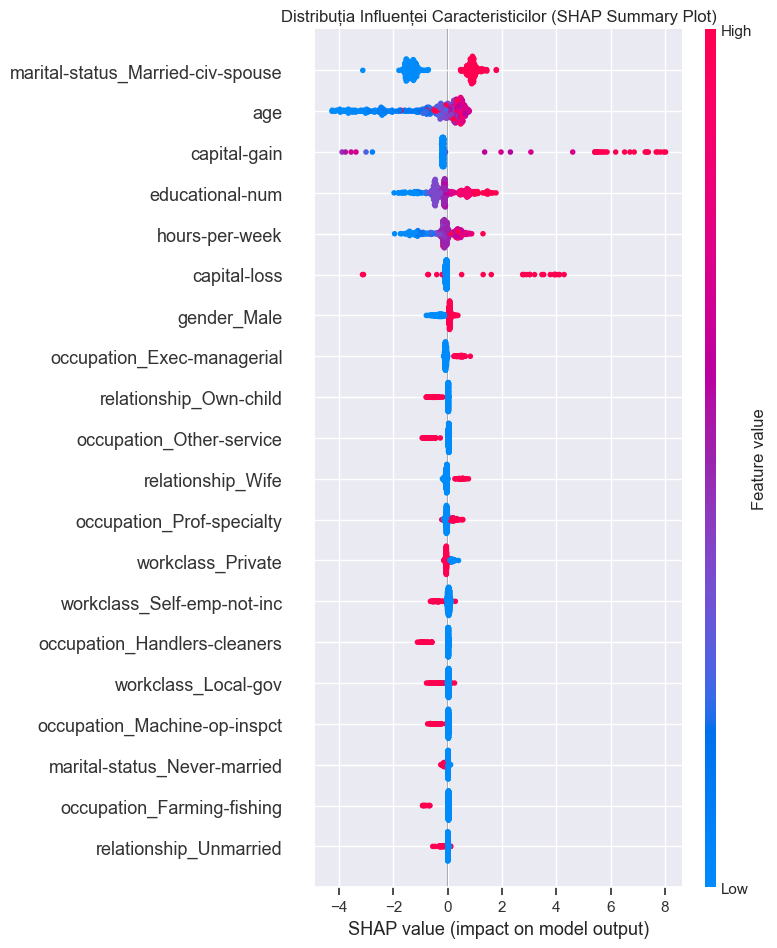

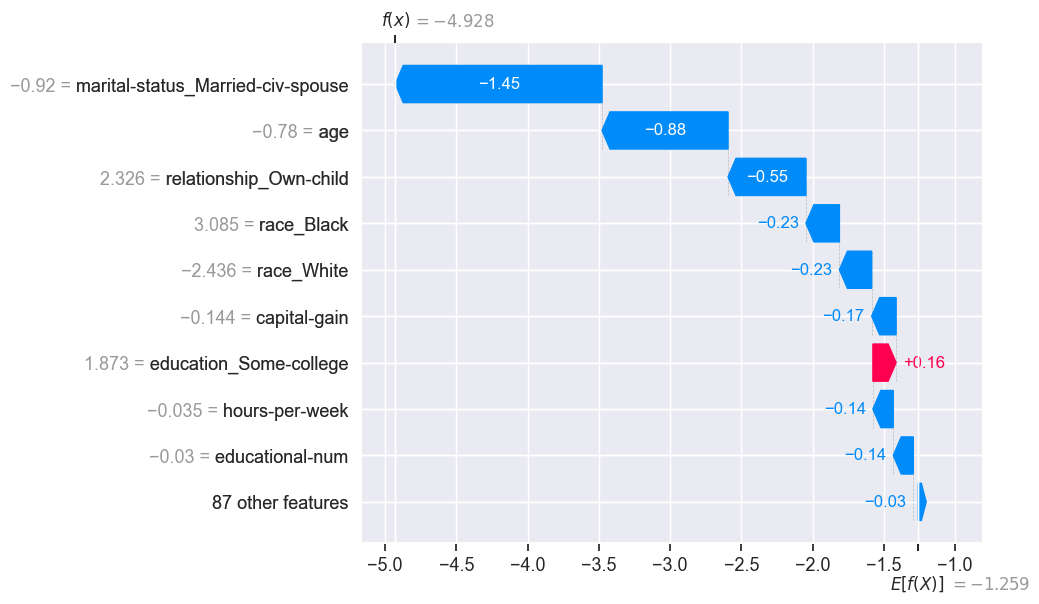

<Figure size 1000x600 with 0 Axes>

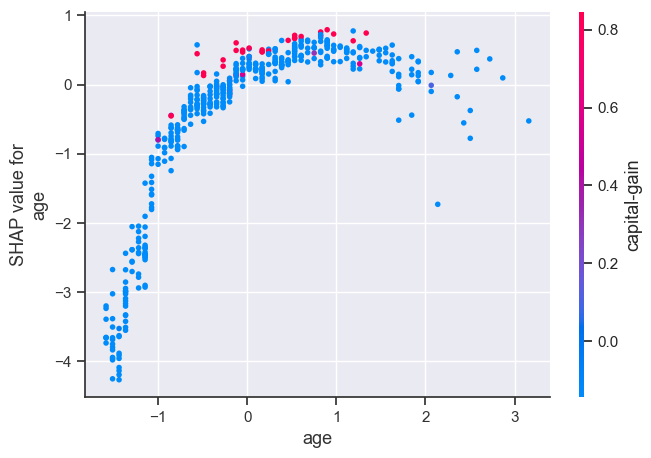

<Figure size 1000x600 with 0 Axes>

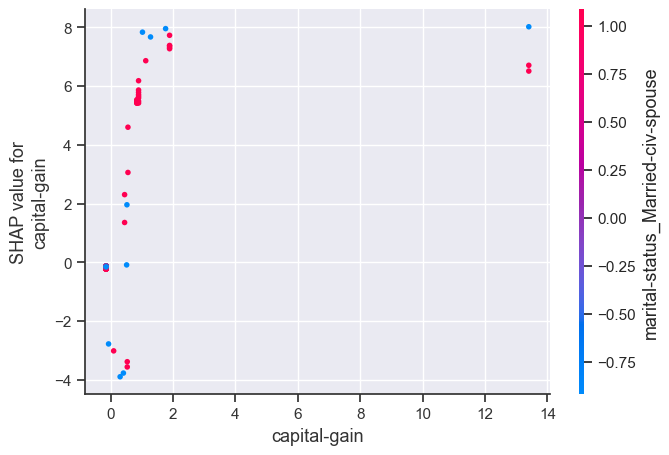

In [28]:
import shap
import matplotlib.pyplot as plt

shap.initjs()
model_final = grid_xgb.best_estimator_
explainer = shap.TreeExplainer(model_final)

nume_coloane = X.columns.tolist()

X_sample = X_test_final[:500]
shap_values = explainer.shap_values(X_sample)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, plot_type="bar", feature_names=nume_coloane, show=False)
plt.title("Importanța Globală a Caracteristicilor (SHAP Bar Plot)")
plt.show()


plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, feature_names=nume_coloane, show=False)
plt.title("Distribuția Influenței Caracteristicilor (SHAP Summary Plot)")
plt.show()


plt.figure(figsize=(10, 6))
exp = shap.Explanation(values=shap_values[0],
                       base_values=explainer.expected_value,
                       data=X_sample[0],
                       feature_names=nume_coloane)
shap.plots.waterfall(exp)


shap.force_plot(explainer.expected_value, shap_values[0], X_sample[0], feature_names=nume_coloane)


features_to_plot = ['age', 'capital-gain']
for feat in features_to_plot:
    if feat in nume_coloane:
        plt.figure()
        shap.dependence_plot(feat, shap_values, X_sample, feature_names=nume_coloane)

In [2]:
import joblib
import matplotlib.pyplot as plt


joblib.dump(grid_cat.best_estimator_, 'catboost_clf_model.joblib')


joblib.dump(list(X_train.columns), 'clf_columns.joblib')


plt.figure(figsize=(10, 6))

plt.savefig('learning_curves_clasificare.png', bbox_inches='tight', dpi=300)
plt.show()

print("✅ Toate resursele pentru Clasificare au fost salvate cu succes!")

NameError: name 'grid_cat' is not defined